### Bài 2: Xây dựng mạng GRU gồm 5 lớp với hidden size là 256 cho bài toán phân loại văn bản. Huấn luyện mô hình này trên bộ dữ liệu UIT-VSFC (Vietnamese Student Feedback Corpus) sử dụng Adam làm phương thức tối ưu tham số và đánh giá độ hiệu quả của mô hình sử dụng độ đo F1.

## Sau đây là code minh họa cho bài toán phân loại chủ đề với 4 nhãn

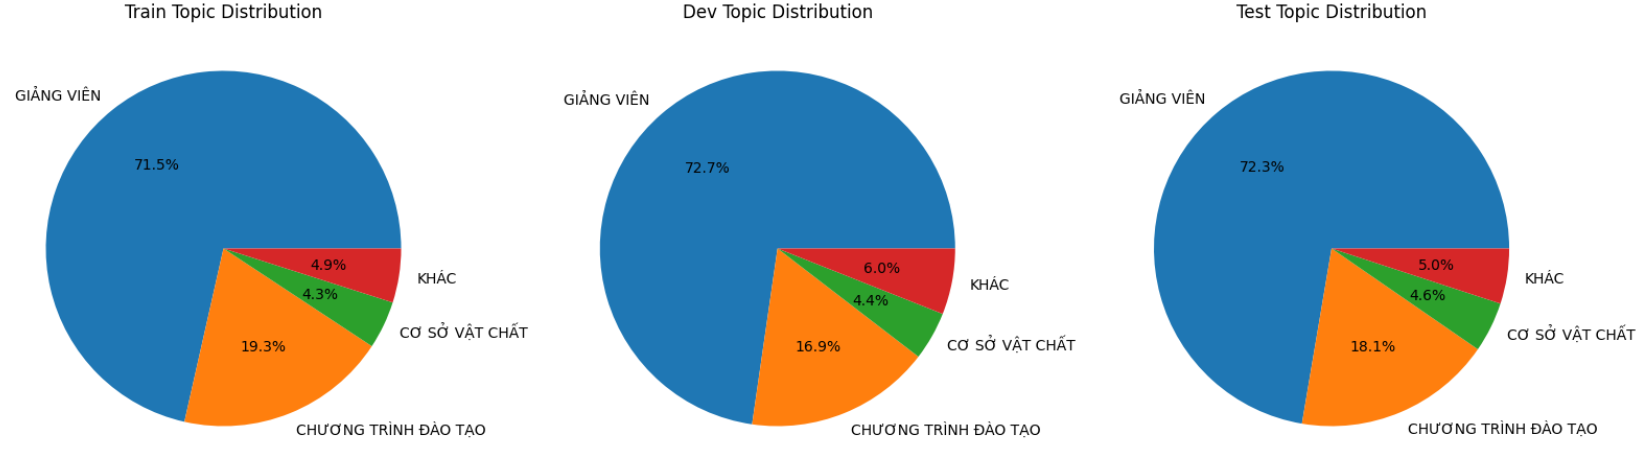

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. Import một số thư viện cần thiết

In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import tensorflow as tf

# 2. Tải dữ liệu đã tiền xử lý

In [19]:
def load_dataset(base_path):
    """
    Hàm đọc dữ liệu từ đường dẫn thư mục chứa các file csv đã tiền xử lý.
    """
    try:
        # Định nghĩa đường dẫn file
        train_path = os.path.join(base_path, 'train_processed.csv')
        dev_path = os.path.join(base_path, 'dev_processed.csv')
        test_path = os.path.join(base_path, 'test_processed.csv')

        # Đọc dữ liệu
        df_train = pd.read_csv(train_path)
        df_dev = pd.read_csv(dev_path)
        df_test = pd.read_csv(test_path)

        # Chuyển đổi dữ liệu input sang chuỗi ký tự (đề phòng giá trị null)
        df_train['segmented_sentence'] = df_train['segmented_sentence'].astype(str)
        df_dev['segmented_sentence'] = df_dev['segmented_sentence'].astype(str)
        df_test['segmented_sentence'] = df_test['segmented_sentence'].astype(str)

        print(f"Kích thước tập Train: {df_train.shape}")
        print(f"Kích thước tập Dev: {df_dev.shape}")
        print(f"Kích thước tập Test: {df_test.shape}")

        return df_train, df_dev, df_test

    except FileNotFoundError as e:
        print(f"Lỗi: Không tìm thấy file dữ liệu. Vui lòng kiểm tra đường dẫn. {e}")
        return None, None, None

# Đường dẫn đến thư mục dữ liệu
DATA_DIR = '/content/drive/MyDrive/MonHocTrenTruong/DS201/Lab-thuc-hanh/Lab-3/preprocessed_UIT-VN_Student_FB'

df_train, df_dev, df_test = load_dataset(DATA_DIR)

Kích thước tập Train: (11426, 6)
Kích thước tập Dev: (1583, 6)
Kích thước tập Test: (3166, 6)


In [20]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11426 entries, 0 to 11425
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   sentence            11426 non-null  object
 1   sentiment           11426 non-null  int64 
 2   topic               11426 non-null  int64 
 3   num_words           11426 non-null  int64 
 4   clean_sentence      11426 non-null  object
 5   segmented_sentence  11426 non-null  object
dtypes: int64(3), object(3)
memory usage: 535.7+ KB


In [21]:
df_train.head()

,sentence,sentiment,topic,num_words,clean_sentence,segmented_sentence
0,slide giáo trình đầy đủ,2,1,6,slide giáo trình đầy đủ,slide giáo_trình đầy_đủ
1,nhiệt tình giảng dạy gần gũi với sinh viên,2,0,11,nhiệt tình giảng dạy gần gũi với sinh viên,nhiệt_tình giảng_dạy gần_gũi với sinh_viên
2,đi học đầy đủ full điểm chuyên cần,0,1,9,đi học đầy đủ full điểm chuyên cần,đi học đầy_đủ full điểm chuyên_cần
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0,18,chưa áp dụng công nghệ thông tin và các thiết ...,chưa áp_dụng công_nghệ thông_tin và các thiết_...
4,thầy giảng bài hay có nhiều bài tập ví dụ nga...,2,0,15,thầy giảng bài hay có nhiều bài tập ví dụ ngay...,thầy giảng bài hay có nhiều bài_tập ví_dụ ngay...


# 3. Mã hóa dữ liệu (Tokenization & Encoding)

## a. Chọn các siêu tham số - Dựa trên phân tích EDA

In [22]:
MAX_LEN = 120           # Độ dài cố định cho mỗi câu (bao phủ đa số dữ liệu)
NUM_CLASSES = 4

## b. Xây dựng các hàm xử lý thủ công - Tạo tập từ điển + encoding

In [23]:
def create_vocab(texts):
    """Tạo bộ từ điển từ danh sách văn bản"""
    vocab_set = set()
    for text in texts:
        # Tách từ theo khoảng trắng (vì đã segmented từ file EDA)
        words = str(text).split()
        vocab_set.update(words)
    return sorted(list(vocab_set))

def create_word_index(vocab_list):
    """Tạo mapping từ chữ sang số"""
    # 0 dành cho Padding, 1 dành cho từ lạ (Unknown)
    word2idx = {'<PAD>': 0, '<UNK>': 1}
    idx = 2
    for word in vocab_list:
        word2idx[word] = idx
        idx += 1
    return word2idx

In [24]:
def encode_and_pad(texts, word2idx, max_len):
    """Chuyển câu văn thành dãy số và padding"""
    data = []
    for text in texts:
        words = str(text).split()
        seq = []
        for w in words:
            # Nếu từ có trong từ điển thì lấy ID, không thì lấy ID của <UNK>
            if w in word2idx:
                seq.append(word2idx[w])
            else:
                seq.append(word2idx['<UNK>'])

        # Thủ tục Padding (Thêm số 0 vào sau)
        if len(seq) < max_len:
            # Nếu ngắn hơn max_len -> thêm 0 vào cuối
            seq = seq + [0] * (max_len - len(seq))
        else:
            # Nếu dài hơn -> cắt bớt
            seq = seq[:max_len]

        data.append(seq)
    return np.array(data)

## THỰC THI

In [25]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Tạo từ điển chỉ trên tập TRAIN (để tránh data leakage)
vocab_list = create_vocab(df_train['segmented_sentence'])
word2idx = create_word_index(vocab_list)
VOCAB_SIZE = len(word2idx) + 1 # +1 để an toàn cho index cuối cùng

print(f"Kích thước từ điển (Vocab size): {VOCAB_SIZE}")

# Mã hóa dữ liệu đầu vào (Input)
print("Đang mã hóa dữ liệu...")
X_train = encode_and_pad(df_train['segmented_sentence'], word2idx, MAX_LEN)
X_dev = encode_and_pad(df_dev['segmented_sentence'], word2idx, MAX_LEN)
X_test = encode_and_pad(df_test['segmented_sentence'], word2idx, MAX_LEN)

# Mã hóa nhãn (Label) sang one-hot
y_train = to_categorical(df_train['topic'], NUM_CLASSES)
y_dev = to_categorical(df_dev['topic'], NUM_CLASSES)
y_test = to_categorical(df_test['topic'], NUM_CLASSES)

# Kiểm tra kết quả
print("\n--- KÍCH THƯỚC DỮ LIỆU SAU KHI XỬ LÝ ---")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_dev:   {X_dev.shape}   | y_dev:   {y_dev.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")
print(f"\nVí dụ mẫu đầu tiên (X_train[0]):\n{X_train[0]}")

Kích thước từ điển (Vocab size): 3391
Đang mã hóa dữ liệu...

--- KÍCH THƯỚC DỮ LIỆU SAU KHI XỬ LÝ ---
X_train: (11426, 120) | y_train: (11426, 4)
X_dev:   (1583, 120)   | y_dev:   (1583, 4)
X_test:  (3166, 120)  | y_test:  (3166, 4)

Ví dụ mẫu đầu tiên (X_train[0]):
[2159  788 3258    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]


Lưu ý, ở đây ta đã thực tiện tách từ, nên số từ có thể nhiều hơn so với thống kê EDA khi chưa tách từ. Câu đầu tiên trong tập train là `slide giáo_trình đầy_đủ` nên khi emcoding ta chỉ có 3 token đại diện cho 3 từ.

# 4. Xây dựng mô hình GRU

In [26]:
#  Cấu hình tham số
VOCAB_SIZE = len(word2idx) + 1 # +1 để an toàn cho index cuối cùng
MAX_LEN = 120 # Như đã trình bày ở trên
NUM_CLASSES = 4
EMBEDDING_DIM = 256

## a. Mô hình theo yêu cầu đề

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam

def build_5_layers_gru(
        vocab_size,
        input_length,
        num_classes,
        EMBEDDING_DIM=256,
        HIDDEN_SIZE=256,
        DROPOUT_RATE=0.4
    ):

    model = tf.keras.Sequential([
        Input(shape=(input_length,)),
        Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, mask_zero=True),

        # GRU layer 1
        GRU(HIDDEN_SIZE, return_sequences=True, name="GRU_1"),
        BatchNormalization(),
        Dropout(DROPOUT_RATE),

        # GRU layer 2
        GRU(HIDDEN_SIZE, return_sequences=True, name="GRU_2"),
        BatchNormalization(),
        Dropout(DROPOUT_RATE),

        # GRU layer 3
        GRU(HIDDEN_SIZE, return_sequences=True, name="GRU_3"),
        BatchNormalization(),
        Dropout(DROPOUT_RATE),

        # GRU layer 4
        GRU(HIDDEN_SIZE, return_sequences=True, name="GRU_4"),
        BatchNormalization(),
        Dropout(DROPOUT_RATE),

        # GRU layer 5 - final (return_sequences=False)
        GRU(HIDDEN_SIZE, return_sequences=False, name="GRU_5"),
        BatchNormalization(),
        Dropout(DROPOUT_RATE),

        Dense(num_classes, activation='softmax', name="Output")
    ], name="Deep_GRU_256_5Layers")

    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=0.0001),
        metrics=['accuracy']
    )

    return model

In [41]:
# Khởi tạo mô hình GRU
print(f"Xây dựng mô hình GRU 5 layers với Vocab Size: {VOCAB_SIZE}")

# Gọi hàm build_5_layers_gru vừa tạo ở trên
_5_layer_gru_model = build_5_layers_gru(VOCAB_SIZE, MAX_LEN, NUM_CLASSES)

_5_layer_gru_model.summary()

Xây dựng mô hình GRU 5 layers với Vocab Size: 3391


Model: "Deep_GRU_256_5Layers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 120, 256)       │       868,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GRU_1 (GRU)                     │ (None, 120, 256)       │       394,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 120, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 120, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GRU_2 (GRU)                     │ (None, 120, 256)       │       394,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 120, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 120, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GRU_3 (GRU)                     │ (None, 120, 256)       │       394,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 120, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 120, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GRU_4 (GRU)                     │ (None, 120, 256)       │       394,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 120, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 120, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GRU_5 (GRU)                     │ (None, 256)            │       394,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,848,004 (10.86 MB)

 Trainable params: 2,845,444 (10.85 MB)

 Non-trainable params: 2,560 (10.00 KB)

In [42]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Định nghĩa Checkpoint
checkpoint = ModelCheckpoint(
    filepath='best_gru_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)


history_gru_5_layers = _5_layer_gru_model.fit(
    X_train, y_train,
    validation_data=(X_dev, y_dev),
    epochs=20,
    batch_size=32,
    verbose=1,
    callbacks=[checkpoint]
)

Epoch 1/20
357/358 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3917 - loss: 1.8213
Epoch 1: val_loss improved from inf to 0.71575, saving model to best_gru_model.keras
358/358 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.3921 - loss: 1.8201 - val_accuracy: 0.7751 - val_loss: 0.7157
Epoch 2/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5952 - loss: 1.1656
Epoch 2: val_loss improved from 0.71575 to 0.69829, saving model to best_gru_model.keras
358/358 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.5953 - loss: 1.1654 - val_accuracy: 0.7922 - val_loss: 0.6983
Epoch 3/20
357/358 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7052 - loss: 0.8782
Epoch 3: val_loss did not improve from 0.69829
358/358 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.7052 - loss: 0.8780 - val_accuracy: 0.7795 - val_loss: 0.9465
Epoch 4/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7697 - loss: 0.7240
Epoch 4: val_loss improved from 0.69829 to 0.65948, saving model to best_gr

In [43]:
from tensorflow.keras.models import load_model
from sklearn.metrics import f1_score, classification_report
import numpy as np

# 1. Load lại model tốt nhất đã lưu (GRU)
print("Đang load lại model GRU tốt nhất từ file...")
# Lưu ý: Tên file phải khớp với tên trong ModelCheckpoint ở bước trước
best_model = load_model('best_gru_model.keras')

# 2. Dự đoán trên tập Test
print("\nĐang dự đoán trên tập Test...")
y_pred_probs = best_model.predict(X_test, verbose=0)
y_pred_class = np.argmax(y_pred_probs, axis=1)
y_true_class = np.argmax(y_test, axis=1)

# 3. Tính độ đo F1-Macro
macro_f1 = f1_score(y_true_class, y_pred_class, average='macro')

print(f"\n>> F1-MACRO (Mô hình GRU 5 lớp): {macro_f1:.4f}")
print("\nChi tiết báo cáo:")
target_names = ['Giảng viên', 'Chương trình', 'Cơ sở vật chất', 'Khác']
print(classification_report(y_true_class, y_pred_class, target_names=target_names))

Đang load lại model GRU tốt nhất từ file...

Đang dự đoán trên tập Test...

>> F1-MACRO (Mô hình GRU 5 lớp): 0.7256

Chi tiết báo cáo:
                precision    recall  f1-score   support

    Giảng viên       0.92      0.91      0.92      2290
  Chương trình       0.68      0.75      0.72       572
Cơ sở vật chất       0.88      0.87      0.88       145
          Khác       0.44      0.36      0.40       159

      accuracy                           0.85      3166
     macro avg       0.73      0.72      0.73      3166
  weighted avg       0.85      0.85      0.85      3166



--- BIỂU ĐỒ HUẤN LUYỆN ---


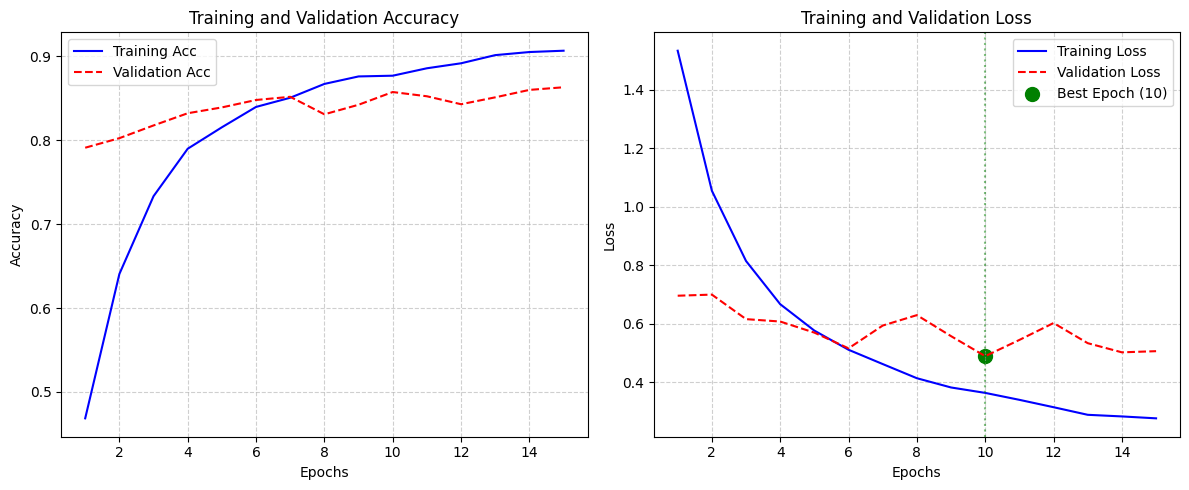

In [31]:
def plot_training_history_improved(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # --- TÌM EPOCH TỐT NHẤT (Dựa trên Val Loss thấp nhất) ---
    best_epoch_idx = np.argmin(val_loss) # Trả về index (bắt đầu từ 0)
    best_epoch_val = best_epoch_idx + 1   # Epoch thực tế (bắt đầu từ 1)
    best_loss = val_loss[best_epoch_idx]

    plt.figure(figsize=(12, 5))

    # 1. Biểu đồ Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Acc')
    plt.plot(epochs, val_acc, 'r--', label='Validation Acc')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6) # Thêm lưới cho dễ nhìn

    # 2. Biểu đồ Loss (Quan trọng nhất)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r--', label='Validation Loss')

    # --- ĐÁNH DẤU ĐIỂM TỐT NHẤT ---
    # Vẽ một điểm màu xanh lá tại epoch có val_loss thấp nhất
    plt.scatter(best_epoch_val, best_loss, s=100, c='green', label=f'Best Epoch ({best_epoch_val})')
    # Vẽ đường gióng xuống
    plt.axvline(x=best_epoch_val, color='green', linestyle=':', alpha=0.5)

    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# --- THỰC THI ---
print("--- BIỂU ĐỒ HUẤN LUYỆN ---")
plot_training_history_improved(history_gru_5_layers)

>Ta thấy kết quả khá tốt vì ta chưa thực hiện các tối ưu nâng cao nào. Lớp `Khác` là lớp bị mất cân bằng nhất vẫn đạt được `0.42 F1 Score`. Sau đây để bắt được lớp này tốt hơn, ta sẽ xem xét dùng kỹ thuật sau:
- 1. Class weight: Tính toán mức độ mất cân bằng dữ liệu, sau đó đánh trọng số phạt cao hơn khi mô hình đoán sai lớp bị mất cân bằng dữ liệu.

  => Tuy nhiên không phải lúc nào cũng tốt, vì nếu mô hình đã học được nhãn bị mất cân bằng, việc gia tăng cho nhãn này sẽ khiến các nhãn khác bị kém nhạy, gây tăng  `False Positive` dãn đến tổng thể `F1 weight` cho các lớp khác có thể đi xuống.

- 2. Gradient Clipping: Khi mạng neural quá sâu, thì khi lan truyền ngược rất có khả năng xảy ra hiện tượng `gradient exposion hoặc gradient vanishing`, gradient clipping là 1 công cụ giới hạn sự gia tăng của gradient qua mỗi lớp backprobation, nếu vượt quá ngưỡng đã xét thì sẽ bị cắt về mức tối đa.
  => Tuy nhiên, nếu nhìn vào biểu đồ training loss, thấy mượt và không bị nhảy lung tung, thì kỹ thuật này có thể không nhiều ý nghĩa, vì gradient không gặp vấn đề khi lan truyền

- 3. Learning Rate Scheduler: Khi hàm loss đang tối ưu tại 1 vùng, do learning rate chưa đủ thấp, nên nó nhảy qua các vùng ven, ta dùng kỹ thuật này với rule base, nếu `val loss` không giảm trong `n` epochs thì sẽ giảm learning rate
  => Tuy nhiên, điều đó có thể làm mô hình không tìm được cực trị toàn cục, mà kẹt lại cực trị địa phương

- 4. Focal Loss: Hàm Loss thông thường (Cross-Entropy) coi trọng mọi mẫu dữ liệu như nhau, nhưng trong dữ liệu mất cân bằng, số lượng của lớp đa số sẽ lấn át, khiến Gradient chủ yếu được tính từ các mẫu này, làm mô hình ít quan tâm đến các mẫu "khó" (lớp thiểu số). Focal Loss `thêm một hệ số điều chỉnh vào hàm Loss`. Nó tự động giảm trọng số của các mẫu dễ (mà mô hình đã dự đoán đúng với độ tin cậy cao) và tập trung mạnh vào các mẫu khó (các mẫu mô hình đang đoán sai).
  => Tác dụng: Giúp cân bằng giữa Precision và Recall một cách mềm dẻo hơn so với việc gán trọng số cứng nhắc như Class Weight, đặc biệt hiệu quả cho các bài toán mất cân bằng dữ liệu nghiêm trọng.

# 5. Cải tiến mô hình

## a. Tối ưu với focal loss + clipnorm

In [32]:
def categorical_focal_loss(gamma=2.0, alpha=0.25):
    """
    Hàm Loss giúp mô hình tập trung vào các mẫu khó (Hard Examples).
    - gamma: Hệ số tập trung. Gamma càng lớn, model càng ít quan tâm đến các mẫu dễ.
    - alpha: Hệ số cân bằng (tương tự class weight nhưng mềm dẻo hơn).
    """
    def focal_loss_fixed(y_true, y_pred):
        # Clip giá trị để tránh log(0) gây lỗi NaN
        y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1.0 - K.epsilon())

        # Tính Cross Entropy truyền thống
        cross_entropy = -y_true * tf.math.log(y_pred)

        # Tính trọng số Focal: (1 - p)^gamma
        # Nếu model đoán đúng (p cao) -> weight nhỏ -> loss nhỏ
        # Nếu model đoán sai (p thấp) -> weight lớn -> loss lớn
        weight = alpha * y_true * tf.math.pow((1 - y_pred), gamma)

        # Tổng hợp loss
        loss = weight * cross_entropy
        return tf.reduce_sum(loss, axis=1)

    return focal_loss_fixed

In [33]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, BatchNormalization, Input, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

def build_5_layers_gru_focal(vocab_size, input_length, num_classes,
                             EMBEDDING_DIM=128, HIDDEN_SIZE=128, DROPOUT_RATE=0.4):

    model = tf.keras.Sequential([
        Input(shape=(input_length,)),

        # QUAN TRỌNG: mask_zero=True để bỏ qua padding
        Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, mask_zero=True),

        # Layer 1
        GRU(HIDDEN_SIZE, return_sequences=True, name="GRU_1"),
        BatchNormalization(),
        Dropout(DROPOUT_RATE),

        # Layer 2
        GRU(HIDDEN_SIZE, return_sequences=True, name="GRU_2"),
        BatchNormalization(),
        Dropout(DROPOUT_RATE),

        # Layer 3
        GRU(HIDDEN_SIZE, return_sequences=True, name="GRU_3"),
        BatchNormalization(),
        Dropout(DROPOUT_RATE),

        # Layer 4
        GRU(HIDDEN_SIZE, return_sequences=True, name="GRU_4"),
        BatchNormalization(),
        Dropout(DROPOUT_RATE),

        # Layer 5 (Cuối cùng)
        GRU(HIDDEN_SIZE, return_sequences=False, name="GRU_5"),
        BatchNormalization(),
        Dropout(DROPOUT_RATE),

        # Output
        Dense(num_classes, activation='softmax', name="Output")
    ], name="Deep_GRU_Focal_Loss")

    # Compile với Focal Loss
    # Giữ clipnorm=1.0 để an toàn, tránh bùng nổ gradient
    model.compile(
        loss=categorical_focal_loss(gamma=2.0, alpha=0.25),
        optimizer=Adam(learning_rate=0.0001, clipnorm=1.0),
        metrics=['accuracy']
    )

    return model

In [34]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    filepath='best_gru_focal.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)


print("Khởi tạo mô hình GRU 5 lớp với Focal Loss...")
# Gọi hàm đã định nghĩa ở Cell 1
model_focal = build_5_layers_gru_focal(VOCAB_SIZE, MAX_LEN, NUM_CLASSES)
model_focal.summary()

print("\nBắt đầu huấn luyện...")
history_focal = model_focal.fit(
    X_train, y_train,
    validation_data=(X_dev, y_dev),
    epochs=20,
    batch_size=32,
    verbose=1,
    callbacks=[checkpoint]
)

Khởi tạo mô hình GRU 5 lớp với Focal Loss...


Model: "Deep_GRU_Focal_Loss"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 120, 128)       │       434,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GRU_1 (GRU)                     │ (None, 120, 128)       │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 120, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 120, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GRU_2 (GRU)                     │ (None, 120, 128)       │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 120, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 120, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GRU_3 (GRU)                     │ (None, 120, 128)       │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 120, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 120, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GRU_4 (GRU)                     │ (None, 120, 128)       │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 120, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 120, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GRU_5 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 932,484 (3.56 MB)

 Trainable params: 931,204 (3.55 MB)

 Non-trainable params: 1,280 (5.00 KB)


Bắt đầu huấn luyện...
Epoch 1/20
357/358 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3200 - loss: 0.3855
Epoch 1: val_loss improved from inf to 0.09344, saving model to best_gru_focal.keras
358/358 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.3202 - loss: 0.3852 - val_accuracy: 0.7599 - val_loss: 0.0934
Epoch 2/20
357/358 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4797 - loss: 0.2356
Epoch 2: val_loss did not improve from 0.09344
358/358 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.4798 - loss: 0.2355 - val_accuracy: 0.7612 - val_loss: 0.1061
Epoch 3/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5850 - loss: 0.1724
Epoch 3: val_loss did not improve from 0.09344
358/358 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.5850 - loss: 0.1723 - val_accuracy: 0.7770 - val_loss: 0.0972
Epoch 4/20
357/358 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6478 - loss: 0.1382
Epoch 4: val_loss improved from 0.09344 to 0.08742, saving model to best_gru_focal.keras
358/3


Đang load lại model tốt nhất...

Đang dự đoán trên tập Test...

>> F1-MACRO (Focal Loss): 0.7394

BÁO CÁO CHI TIẾT:
                precision    recall  f1-score   support

    Giảng viên       0.93      0.91      0.92      2290
  Chương trình       0.68      0.73      0.70       572
Cơ sở vật chất       0.90      0.89      0.90       145
          Khác       0.45      0.43      0.44       159

      accuracy                           0.85      3166
     macro avg       0.74      0.74      0.74      3166
  weighted avg       0.86      0.85      0.85      3166



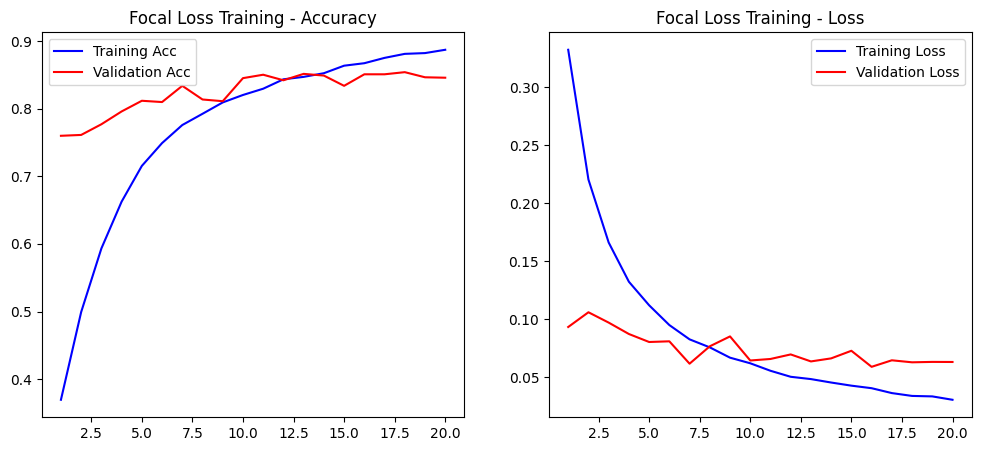

In [35]:
# --- 2. LOAD LẠI MODEL TỐT NHẤT ---
print("\nĐang load lại model tốt nhất...")
# Vì dùng hàm loss tự viết, cần báo cho Keras biết khi load
# Chúng ta khởi tạo lại hàm loss để lấy tên hàm bên trong (focal_loss_fixed)
dummy_loss = categorical_focal_loss(gamma=2.0, alpha=0.25)

best_model_focal = load_model(
    'best_gru_focal.keras',
    custom_objects={'focal_loss_fixed': dummy_loss}
)

# --- 3. ĐÁNH GIÁ TRÊN TẬP TEST ---
print("\nĐang dự đoán trên tập Test...")
y_pred_probs = best_model_focal.predict(X_test, verbose=0)
y_pred_class = np.argmax(y_pred_probs, axis=1)
y_true_class = np.argmax(y_test, axis=1)

# Tính F1-Macro
macro_f1 = f1_score(y_true_class, y_pred_class, average='macro')
print(f"\n>> F1-MACRO (Focal Loss): {macro_f1:.4f}")

# Chi tiết từng lớp
target_names = ['Giảng viên', 'Chương trình', 'Cơ sở vật chất', 'Khác']
print("\nBÁO CÁO CHI TIẾT:")
print(classification_report(y_true_class, y_pred_class, target_names=target_names))

# --- 4. VẼ BIỂU ĐỒ SO SÁNH (Optional) ---
def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training Acc')
    plt.plot(epochs, val_acc, 'r', label='Validation Acc')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training Loss')
    plt.plot(epochs, val_loss, 'r', label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.show()

plot_history(history_focal, "Focal Loss Training")

Khi sử dụng hàm Focal Loss (gamma=2.0, alpha=0.25), F1-Macro đạt 0.7401.So sánh với Baseline (Cross-Entropy): Kết quả gần như tương đương (0.74 vs 0.72).

- Lớp Khác (thiểu số): F1 tăng nhẹ lên 0.44 (so với 0.40 của Baseline).

- Lớp Cơ sở vật chất: F1 đạt 0.90 (so với 0.88 của Baseline).

- Lớp Chương trình đào tạo: F1 giảm nhẹ xuống 0.70 (so với 0.72 của Baseline).

=> Kết luận: Focal Loss hoạt động đúng như lý thuyết là tập trung vào các mẫu khó (lớp Khác và CSVC), giúp cải thiện nhẹ hiệu suất ở các lớp này. Tuy nhiên, sự cải thiện không đáng kể lắm khi có giảm nhẹ ở lớp trung bình (Chương trình đào tạo).

## b. Tối ưu focal loss + clipnorm + learningrate_schdedule

In [36]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

checkpoint_scheduler = ModelCheckpoint(
    filepath='best_gru_focal_scheduled.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# Nếu val_loss không giảm sau 3 epochs, chia đôi learning rate
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

model_focal_scheduled = build_5_layers_gru_focal(VOCAB_SIZE, MAX_LEN, NUM_CLASSES)

history_focal_scheduled = model_focal_scheduled.fit(
    X_train, y_train,
    validation_data=(X_dev, y_dev),
    epochs=20,
    batch_size=32,
    verbose=1,
    callbacks=[checkpoint_scheduler,lr_scheduler]
)

# Cần khai báo custom_objects cho hàm loss khi load
dummy_loss = categorical_focal_loss(gamma=2.0, alpha=0.25)
best_model_scheduled = load_model(
    'best_gru_focal_scheduled.keras',
    custom_objects={'focal_loss_fixed': dummy_loss}
)

print("\nĐang dự đoán trên tập Test...")
y_pred_probs = best_model_scheduled.predict(X_test, verbose=0)
y_pred_class = np.argmax(y_pred_probs, axis=1)
y_true_class = np.argmax(y_test, axis=1)

# Tính F1-Macro
macro_f1 = f1_score(y_true_class, y_pred_class, average='macro')
print(f"\n>> F1-MACRO (Focal Loss + Scheduler): {macro_f1:.4f}")

# Báo cáo chi tiết
target_names = ['Giảng viên', 'Chương trình đào tạo', 'Cơ sở vật chất', 'Khác']
print(classification_report(y_true_class, y_pred_class, target_names=target_names))

Epoch 1/20
357/358 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3535 - loss: 0.3861
Epoch 1: val_loss improved from inf to 0.09258, saving model to best_gru_focal_scheduled.keras
358/358 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.3538 - loss: 0.3858 - val_accuracy: 0.7732 - val_loss: 0.0926 - learning_rate: 1.0000e-04
Epoch 2/20
357/358 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5220 - loss: 0.2258
Epoch 2: val_loss did not improve from 0.09258
358/358 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.5220 - loss: 0.2257 - val_accuracy: 0.7486 - val_loss: 0.1196 - learning_rate: 1.0000e-04
Epoch 3/20
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5906 - loss: 0.1741
Epoch 3: val_loss improved from 0.09258 to 0.08414, saving model to best_gru_focal_scheduled.keras
358/358 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.5907 - loss: 0.1740 - val_accuracy: 0.7991 - val_loss: 0.0841 - learning_rate: 1.0000e-04
Epoch 4/20
356/358 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accu

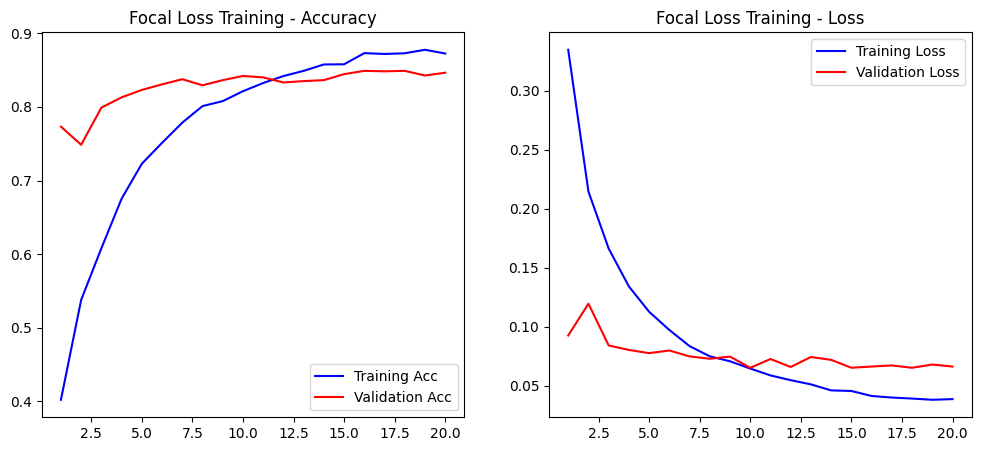

In [38]:
def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training Acc')
    plt.plot(epochs, val_acc, 'r', label='Validation Acc')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training Loss')
    plt.plot(epochs, val_loss, 'r', label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.show()

plot_history(history_focal_scheduled, "Focal Loss Training")

Kết hợp focal lost và learning_rate schedule không phải lúc nào cũng cho kết quả tốt. Ở đây ta thấy các lớp đa số đều chứng kiến sự giảm nhẹ, còn lớp thiểu số `khác` giảm từ `0.44` xuống `0.37`. Điều này đi ngược lại với mục tiêu của focal loss là tối ưu lớp thiểu số.

=> Nguyên nhân: Focal Loss làm giảm biên độ của Gradient (do hạ thấp trọng số các mẫu dễ), mà các mẫu này lại chiếm đa số

=>  khiến Loss giảm chậm. Scheduler đã hiểu nhầm đây là dấu hiệu bão hòa và giảm Learning Rate quá sớm, khiến mô hình bị "kẹt" và không thể học tiếp các mẫu khó.